In [2]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import os
from PIL import Image
from matplotlib.pyplot import GridSpec
import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF
from snntorch import utils
from sklearn.preprocessing import LabelEncoder

In [3]:
DATA_DIR = "../../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [4]:
class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [ ]:
train_df = pd.read_csv(f"{DATASET_DIR}/train1.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test1.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val1.csv")

In [ ]:
# shuffle val and test
val_df = val_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [6]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_1119705.png,1
1,image_2975672.png,1
2,image_6489183.png,1
3,image_2675390.png,1
4,image_5559062.png,1


In [7]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=transform)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=transform)

In [ ]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

In [59]:
sample_weights

array([3. , 3. , 3. , ..., 0.6, 0.6, 0.6])

In [9]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Notes
1. With initial architecture and 4 steps of training, the model achieved 0.93 accuracy on the test set.
2. 3 layer reduced the accuracy to 0.92. reverted back to 4 layers. and using 2nd conv2d output as 64 and no padding instead of 32 and using a transform normalize

In [10]:
class BasicSNN(nn.Module):
    def __init__(self, beta=0.5, num_steps=4, num_classes=2):
        super(BasicSNN, self).__init__()

        self.num_steps = num_steps
        self.num_classes = num_classes
        self.spike_grad = surrogate.fast_sigmoid(slope=25)

        self.conv1 = nn.Conv2d(1, 16, kernel_size=4, stride=4)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=2, stride=2)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)


        # flattened_size = 32 * (32 // 4) * (32 // 4)

        self.fc1 = nn.Linear(32 * 4 * 4, self.num_classes)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)

        self.spk1 = None
        self.spk2 = None


    def forward(self, x):
        mem1 = self.lif1.reset_mem()
        mem2 = self.lif2.reset_mem()
        mem3 = self.lif3.reset_mem()

        spk_rec = []
        mem_rec = []

        spk1_rec = []
        spk2_rec = []

        for step in range(self.num_steps):
            # cur1 = F.max_pool2d(self.conv1(x), 2)
            cur1 = self.conv1(x)
            spike1, mem1 = self.lif1(cur1, mem1)

            # print(spike1.shape)

            # cur2 = F.max_pool2d(self.conv2(spike1), 2)
            cur2 = self.conv2(spike1)
            spike2, mem2 = self.lif2(cur2, mem2)

            # print(spike2.shape)
            flatten = spike2.flatten(1)

            # print(flatten.shape)
            cur3 = self.fc1(flatten)
            spike3, mem3 = self.lif3(cur3, mem3)

            spk1_rec.append(spike1)
            spk2_rec.append(spike2)

            spk_rec.append(spike3)
            mem_rec.append(mem3)

        self.spk1 = torch.stack(spk1_rec, dim=0)
        self.spk2 = torch.stack(spk2_rec, dim=0)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

In [62]:
dummy_input = torch.zeros(40, 1, 32, 32)
model = BasicSNN()
out, mem = model(dummy_input)

In [63]:
spk1 = model.spk1
spk2 = model.spk2

spk1.shape, spk2.shape, out.shape

(torch.Size([4, 40, 16, 8, 8]),
 torch.Size([4, 40, 32, 4, 4]),
 torch.Size([4, 40, 2]))

For `torch.stack`, the `dim` affects the output of the function.
1. `dim=1` -> shape: `[batch_size, time_step, output_neurons]`
2. `dim=0` -> shape: `[time_step, batch_size, output_neurons]`
3. `dim=-1` -> shape: `[batch_size, output_neurons, time_step]`


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calculate_class_metrics(y_true, y_pred):

    benign_precision = precision_score(y_true, y_pred, pos_label=1)
    benign_recall = recall_score(y_true, y_pred, pos_label=1)
    benign_f1 = f1_score(y_true, y_pred, pos_label=1)

    malicious_precision = precision_score(y_true, y_pred, pos_label=0)
    malicious_recall = recall_score(y_true, y_pred, pos_label=0)
    malicious_f1 = f1_score(y_true, y_pred, pos_label=0)



    metrics = {
        'benign': {
            'precision': benign_precision,
            'recall': benign_recall,
            'f1': benign_f1
        },
        'malicious': {
            'precision': malicious_precision,
            'recall': malicious_recall,
            'f1': malicious_f1
        }
    }
    
    return metrics

In [ ]:
def train_model(train_dataloader, val_dataloader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=None, device="cuda", dt_ms=1.0):
    # Initialize model
    model = BasicSNN(num_steps=4).to(device)
    
    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, 
                                 weight_decay=weight_decay if weight_decay else 0,
                                 betas=(0.9, 0.999))
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=num_epochs // 5, T_mult=1, eta_min=1e-6, last_epoch=-1)

    # Initialize metrics tracking dictionary
    metrics = {
        'train': {
            'loss': [],           # Per batch loss
            'avg_loss': [],       # Per epoch average loss
            'acc': [],            # Per epoch accuracy
            'f1': [],             # Per epoch overall F1
            'class_metrics': [],  # Per epoch class-specific metrics
        },
        'val': {
            'loss': [],
            'avg_loss': [],
            'acc': [],
            'f1': [],
            'class_metrics': [],
        },
        # Spike statistics
        'spike_stats': {
            'train': {
                'avg_spikes_per_neuron': [],
                'spike_rate_hz': [],
                'spike_count': [],
                'active_neurons_percent': [],
                'threshold_proximity_avg': [],
                'threshold_proximity_std': [],
                'membrane_potential_avg': [],
                'membrane_potential_std': [],
            },
            'val': {
                'avg_spikes_per_neuron': [],
                'spike_rate_hz': [],
                'spike_count': [],
                'active_neurons_percent': [],
                'threshold_proximity_avg': [],
                'threshold_proximity_std': [],
                'membrane_potential_avg': [],
                'membrane_potential_std': [],
            },
            'firing_rate_stability': [], # General stability metric
        }
    }

    best_val_f1 = -1.0  # Track best F1 score instead of loss
    best_model_state = None
    neuron_cache = {'layer1': None, 'layer2': None, 'output': None}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # --- TRAINING PHASE ---
        model.train()
        # Per-epoch tracking
        epoch_data = {
            'train_loss': 0,
            'train_correct': 0.0,
            'train_total': 0,
            'spike_count': 0,
            'active_neurons': 0,
            'total_neurons': 0,
            'total_possible': 0,
            'train_preds': [],
            'train_targets': [],
            'sum_mem': 0.0,
            'sum_sq_mem': 0.0,
            'total_mem_samples': 0,
            'proximity_sum': 0.0,
            'proximity_sq_sum': 0.0,
            'proximity_samples': 0,
        }

        for data, targets in tqdm(train_dataloader, desc="Training"):
            data, targets = data.to(device), targets.to(device)
            utils.reset(model)

            # Forward pass
            spk_rec, mem_rec = model(data)

            # Calculate neuron counts once
            if neuron_cache['layer1'] is None:
                with torch.no_grad():
                    neuron_cache['layer1'] = model.spk1[0, 0].numel()
                    neuron_cache['layer2'] = model.spk2[0, 0].numel()
                    neuron_cache['output'] = spk_rec.size(-1)

            # Loss calculation
            loss = loss_fn(spk_rec, targets)
            epoch_data['train_loss'] += loss.item()
            metrics['train']['loss'].append(loss.item())

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # --- METRICS CALCULATION ---
            with torch.no_grad():
                # Accuracy
                acc = SF.accuracy_rate(spk_rec, targets)
                epoch_data['train_correct'] += acc * data.size(0)
                epoch_data['train_total'] += data.size(0)

                # Predictions for F1
                preds = torch.argmax(spk_rec.sum(dim=0), dim=1)
                epoch_data['train_preds'].append(preds.cpu())
                epoch_data['train_targets'].append(targets.cpu())

                # Spike statistics
                spike_tensor = spk_rec.detach()
                layer1_spikes = model.spk1.detach()
                layer2_spikes = model.spk2.detach()

                batch_spike_count = (spike_tensor.sum() + layer1_spikes.sum() + layer2_spikes.sum()).item()
                epoch_data['spike_count'] += batch_spike_count

                batch_size = data.size(0)
                time_steps = spike_tensor.size(0)
                total_batch_neurons = (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size * time_steps
                epoch_data['total_neurons'] += total_batch_neurons

                active1 = (layer1_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active2 = (layer2_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active3 = (spike_tensor.sum(dim=0) > 0).sum(dim=1).sum().item()
                epoch_data['active_neurons'] += active1 + active2 + active3
                epoch_data['total_possible'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size

                # Membrane statistics
                if mem_rec is not None:
                    mem_tensor = mem_rec.detach()
                    epoch_data['sum_mem'] += mem_tensor.sum().item()
                    epoch_data['sum_sq_mem'] += (mem_tensor**2).sum().item()
                    epoch_data['total_mem_samples'] += mem_tensor.numel()

                    proximity = torch.abs(mem_tensor - 0.3)
                    epoch_data['proximity_sum'] += proximity.sum().item()
                    epoch_data['proximity_sq_sum'] += (proximity**2).sum().item()
                    epoch_data['proximity_samples'] += proximity.numel()

        # --- EPOCH TRAINING METRICS ---
        avg_train_loss = epoch_data['train_loss'] / len(train_dataloader)
        metrics['train']['avg_loss'].append(avg_train_loss)
        
        train_acc = epoch_data['train_correct'] / epoch_data['train_total'] if epoch_data['train_total'] > 0 else 0.0
        metrics['train']['acc'].append(train_acc)

        # Calculate F1 score and class-specific metrics
        train_preds = torch.cat(epoch_data['train_preds']).numpy() if len(epoch_data['train_preds']) > 0 else np.array([])
        train_targets = torch.cat(epoch_data['train_targets']).numpy() if len(epoch_data['train_targets']) > 0 else np.array([])
        
        # Overall F1 score (binary average)
        train_f1 = f1_score(train_targets, train_preds, average='weighted') if len(train_preds) > 0 else 0.0
        metrics['train']['f1'].append(train_f1)
        
        # Calculate class-specific metrics
        if len(train_preds) > 0:
            train_class_metrics = calculate_class_metrics(train_targets, train_preds)
            metrics['train']['class_metrics'].append(train_class_metrics)
        else:
            train_class_metrics = {
                'benign': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
                'malicious': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
            }
            metrics['train']['class_metrics'].append(train_class_metrics)

        # Spike metrics
        avg_spikes_per_neuron = epoch_data['spike_count'] / epoch_data['total_neurons'] if epoch_data['total_neurons'] > 0 else 0.0
        active_percent = (epoch_data['active_neurons'] / epoch_data['total_possible']) * 100 if epoch_data['total_possible'] > 0 else 0.0
        
        metrics['spike_stats']['train']['avg_spikes_per_neuron'].append(avg_spikes_per_neuron)
        metrics['spike_stats']['train']['spike_rate_hz'].append(avg_spikes_per_neuron * (1000 / dt_ms))
        metrics['spike_stats']['train']['spike_count'].append(epoch_data['spike_count'])
        metrics['spike_stats']['train']['active_neurons_percent'].append(active_percent)

        # Membrane metrics
        if epoch_data['total_mem_samples'] > 0:
            avg_mem = epoch_data['sum_mem'] / epoch_data['total_mem_samples']
            std_mem = np.sqrt((epoch_data['sum_sq_mem'] / epoch_data['total_mem_samples']) - avg_mem**2)
        else:
            avg_mem = std_mem = 0.0
        metrics['spike_stats']['train']['membrane_potential_avg'].append(avg_mem)
        metrics['spike_stats']['train']['membrane_potential_std'].append(std_mem)

        # Threshold proximity
        if epoch_data['proximity_samples'] > 0:
            avg_prox = epoch_data['proximity_sum'] / epoch_data['proximity_samples']
            std_prox = np.sqrt((epoch_data['proximity_sq_sum'] / epoch_data['proximity_samples']) - avg_prox**2)
        else:
            avg_prox = std_prox = 0.0
        metrics['spike_stats']['train']['threshold_proximity_avg'].append(avg_prox)
        metrics['spike_stats']['train']['threshold_proximity_std'].append(std_prox)

        print(f"Train Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Benign - P: {train_class_metrics['benign']['precision']:.4f}, R: {train_class_metrics['benign']['recall']:.4f}, F1: {train_class_metrics['benign']['f1']:.4f}")
        print(f"Malicious - P: {train_class_metrics['malicious']['precision']:.4f}, R: {train_class_metrics['malicious']['recall']:.4f}, F1: {train_class_metrics['malicious']['f1']:.4f}")
        print(f"Spikes/Neuron: {avg_spikes_per_neuron:.4f} ({avg_spikes_per_neuron*(1000/dt_ms):.1f}Hz)")
        print(f"Active Neurons: {active_percent:.1f}%")
        print("-" * 50)

        # --- VALIDATION PHASE ---
        with torch.no_grad():
            model.eval()
            # Per-epoch validation tracking
            val_data = {
                'val_loss': 0,
                'val_correct': 0.0,
                'val_total': 0,
                'spike_count': 0,
                'total_neurons': 0,
                'active_neurons': 0,
                'total_possible': 0,
                'val_preds': [],
                'val_targets': [],
                'sum_mem': 0.0,
                'sum_sq_mem': 0.0,
                'total_mem_samples': 0,
                'proximity_sum': 0.0,
                'proximity_sq_sum': 0.0,
                'proximity_samples': 0,
            }
            
            for data, targets in tqdm(val_dataloader, desc="Validation"):
                data, targets = data.to(device), targets.to(device)
                utils.reset(model)

                spk_rec, mem_rec = model(data)

                # Loss and accuracy
                loss = loss_fn(spk_rec, targets)
                val_data['val_loss'] += loss.item()
                metrics['val']['loss'].append(loss.item())

                acc = SF.accuracy_rate(spk_rec, targets)
                val_data['val_correct'] += acc * data.size(0)
                val_data['val_total'] += data.size(0)

                # Predictions for F1
                preds = torch.argmax(spk_rec.sum(dim=0), dim=1)
                val_data['val_preds'].append(preds.cpu())
                val_data['val_targets'].append(targets.cpu())

                # Spike statistics
                spike_tensor = spk_rec.detach()
                layer1_spikes = model.spk1.detach()
                layer2_spikes = model.spk2.detach()

                batch_spike = (spike_tensor.sum() + layer1_spikes.sum() + layer2_spikes.sum()).item()
                val_data['spike_count'] += batch_spike

                batch_size = data.size(0)
                time_steps = spike_tensor.size(0)
                val_data['total_neurons'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size * time_steps

                active1 = (layer1_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active2 = (layer2_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active3 = (spike_tensor.sum(dim=0) > 0).sum(dim=1).sum().item()
                val_data['active_neurons'] += active1 + active2 + active3
                val_data['total_possible'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size

                # Membrane stats
                if mem_rec is not None:
                    mem_tensor = mem_rec.detach()
                    val_data['sum_mem'] += mem_tensor.sum().item()
                    val_data['sum_sq_mem'] += (mem_tensor**2).sum().item()
                    val_data['total_mem_samples'] += mem_tensor.numel()

                    proximity = torch.abs(mem_tensor - 0.3)
                    val_data['proximity_sum'] += proximity.sum().item()
                    val_data['proximity_sq_sum'] += (proximity**2).sum().item()
                    val_data['proximity_samples'] += proximity.numel()

        # --- VALIDATION METRICS ---
        avg_val_loss = val_data['val_loss'] / len(val_dataloader)
        val_acc = val_data['val_correct'] / val_data['val_total'] if val_data['val_total'] > 0 else 0.0
        metrics['val']['avg_loss'].append(avg_val_loss)
        metrics['val']['acc'].append(val_acc)

        # Calculate validation F1 and class-specific metrics
        val_preds = torch.cat(val_data['val_preds']).numpy() if len(val_data['val_preds']) > 0 else np.array([])
        val_targets = torch.cat(val_data['val_targets']).numpy() if len(val_data['val_targets']) > 0 else np.array([])
        
        # Overall F1 score (binary average)
        val_f1 = f1_score(val_targets, val_preds, average='weighted') if len(val_preds) > 0 else 0.0
        metrics['val']['f1'].append(val_f1)
        
        # Calculate class-specific metrics
        if len(val_preds) > 0:
            val_class_metrics = calculate_class_metrics(val_targets, val_preds)
            metrics['val']['class_metrics'].append(val_class_metrics)
        else:
            val_class_metrics = {
                'benign': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
                'malicious': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
            }
            metrics['val']['class_metrics'].append(val_class_metrics)

        # Spike metrics
        val_avg_spikes = val_data['spike_count'] / val_data['total_neurons'] if val_data['total_neurons'] > 0 else 0.0
        val_active_percent = (val_data['active_neurons'] / val_data['total_possible']) * 100 if val_data['total_possible'] > 0 else 0.0
        
        metrics['spike_stats']['val']['avg_spikes_per_neuron'].append(val_avg_spikes)
        metrics['spike_stats']['val']['spike_rate_hz'].append(val_avg_spikes * (1000 / dt_ms))
        metrics['spike_stats']['val']['spike_count'].append(val_data['spike_count'])
        metrics['spike_stats']['val']['active_neurons_percent'].append(val_active_percent)

        # Membrane metrics
        if val_data['total_mem_samples'] > 0:
            avg_val_mem = val_data['sum_mem'] / val_data['total_mem_samples']
            std_val_mem = np.sqrt((val_data['sum_sq_mem'] / val_data['total_mem_samples']) - avg_val_mem**2)
        else:
            avg_val_mem = std_val_mem = 0.0

        # Threshold proximity
        if val_data['proximity_samples'] > 0:
            avg_val_prox = val_data['proximity_sum'] / val_data['proximity_samples']
            std_val_prox = np.sqrt((val_data['proximity_sq_sum'] / val_data['proximity_samples']) - avg_val_prox**2)
        else:
            avg_val_prox = std_val_prox = 0.0
        metrics['spike_stats']['val']['threshold_proximity_avg'].append(avg_val_prox)
        metrics['spike_stats']['val']['threshold_proximity_std'].append(std_val_prox)

        metrics['spike_stats']['val']['membrane_potential_avg'].append(avg_val_mem)
        metrics['spike_stats']['val']['membrane_potential_std'].append(std_val_mem)

        # --- MODEL CHECKPOINTING ---
        # Keep using overall binary F1 for best model selection (as requested)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'val_loss': avg_val_loss,
                'val_acc': val_acc,
                'val_f1': val_f1,
                'val_class_metrics': val_class_metrics
            }
            print(f"New best validation F1: {best_val_f1:.4f}")

        # --- EPOCH REPORTING ---
        print(f"Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        print(f"Benign - P: {val_class_metrics['benign']['precision']:.4f}, R: {val_class_metrics['benign']['recall']:.4f}, F1: {val_class_metrics['benign']['f1']:.4f}")
        print(f"Malicious - P: {val_class_metrics['malicious']['precision']:.4f}, R: {val_class_metrics['malicious']['recall']:.4f}, F1: {val_class_metrics['malicious']['f1']:.4f}")
        print(f"Spikes/Neuron: {val_avg_spikes:.4f} ({val_avg_spikes*(1000/dt_ms):.1f}Hz)")
        print(f"Active Neurons: Train {active_percent:.1f}% | Val {val_active_percent:.1f}%")
        print(f"Membrane Potential: Train {avg_mem:.4f} ± {std_mem:.4f} | Val {avg_val_mem:.4f} ± {std_val_mem:.4f}")
        print(f"Threshold Proximity: Train {avg_prox:.4f} ± {std_prox:.4f} | Val {avg_val_prox:.4f} ± {std_val_prox:.4f}")
        print("-" * 50)

        # Update scheduler
        scheduler.step()

    # --- FINAL SAVING ---
    metrics['best_val_f1'] = best_val_f1

    if model_savepath:
        # Save final model
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'metrics': metrics
        }, model_savepath)

        # Save best model
        if best_model_state:
            best_path = model_savepath.replace(".pt", "_best.pt")
            torch.save(best_model_state, best_path)
            print(f"Best model (F1={best_val_f1:.4f}) saved to {best_path}")

    return model, metrics

In [11]:
base_dir = "../../models/checkpoints/basic_snn"
model_savepath = f"{base_dir}/model_nopooling_v4.pt"

os.makedirs(base_dir, exist_ok=True)

In [1]:
savepath = model_savepath

device = "cuda" if torch.cuda.is_available() else "cpu"

# calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(train_df_encoded["Label"]), y=train_df_encoded["Label"])

NameError: name 'model_savepath' is not defined

In [67]:
loss_fn = SF.ce_rate_loss(weight=class_weights)

In [68]:
model, history = train_model(train_data_loader, val_data_loader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=savepath, device=device, dt_ms=1.0)

# model, history = train_model(train_data_loader_spike, val_data_loader_spike, loss_fn, lr=1e-2, weight_decay=None, num_epochs=50, model_savepath=savepath, device=device, dt_ms=1.0)

Epoch 1/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [00:56<00:00, 13.32it/s]


Train Loss: 0.6719
Train Spikes/Neuron: 0.2046 (204.6Hz)
Active Neurons: 40.2%
--------------------------------------------------


Validation: 100%|██████████| 750/750 [00:51<00:00, 14.44it/s]


New best validation loss: 0.4192
Val Loss: 0.4192 | Val Acc: 0.8296
Val Spikes/Neuron: 0.1989 (198.9Hz)
Active Neurons: Train 40.2% | Val 37.8%
Membrane Potential: Train 0.1077 ± 2.9234 | Val 0.0224 ± 3.6465
Threshold Proximity: Train 2.1037 ± 2.0391 | Val 2.7494 ± 2.4113
--------------------------------------------------
Epoch 2/50
--------------------------------------------------


...

Val Loss: 0.4147 | Val Acc: 0.8349
Val Spikes/Neuron: 0.1986 (198.6Hz)
Active Neurons: Train 30.9% | Val 30.6%
Membrane Potential: Train -0.9638 ± 45.7550 | Val -0.0975 ± 38.4806
Threshold Proximity: Train 31.7383 ± 32.9818 | Val 25.8997 ± 28.4626
--------------------------------------------------
Epoch 50/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [00:50<00:00, 14.93it/s]


Train Loss: 0.6257
Train Spikes/Neuron: 0.2013 (201.3Hz)
Active Neurons: 31.0%
--------------------------------------------------


Validation: 100%|██████████| 750/750 [00:43<00:00, 17.22it/s]


Val Loss: 0.4147 | Val Acc: 0.8348
Val Spikes/Neuron: 0.1986 (198.6Hz)
Active Neurons: Train 31.0% | Val 30.6%
Membrane Potential: Train -1.1692 ± 45.8189 | Val -0.2053 ± 38.4936
Threshold Proximity: Train 31.8415 ± 32.9794 | Val 26.0065 ± 28.3845
--------------------------------------------------
Best model (loss=0.4146) saved to ../../models/checkpoints/basic_snn/model_nopooling_v4_best.pt


In [13]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

test_dataset = CustomDataset(test_data_encoded, f"{DATASET_DIR}/images", transform=transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
best_model_path = savepath.replace(".pt", "_best.pt")

checkpoint = torch.load(best_model_path, weights_only=False)
best_model = BasicSNN(num_steps=4).to(device)
best_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [ ]:
# sample 10000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(6000, random_state=42)

# shuffle the data
test_data_sample = test_data_sample.sample(frac=1, random_state=42).reset_index(drop=True) 

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
def calculate_accuracy2(model, test_data_loader_sample, device, class_names=None):
    y_true = torch.tensor([], dtype=torch.long, device=device)
    y_pred = torch.tensor([], dtype=torch.long, device=device)

    with torch.no_grad():
        model.eval()
        correct = 0
        total = 0

        for images, labels in tqdm(test_data_loader_sample, desc="Calculating Accuracy"):
            images, labels = images.to(device), labels.to(device)
            utils.reset(model)  # Reset neuron states per batch

            spk_rec, _ = model(images)  # Shape: [num_steps, batch_size, num_classes]
            spk_mean = spk_rec.sum(dim=0)  # Aggregate spikes over time
            preds = spk_mean.argmax(dim=1)  # Get predictions

            # Append predictions and labels
            y_true = torch.cat((y_true, labels))
            y_pred = torch.cat((y_pred, preds))

            # Compute batch accuracy
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        # Convert to numpy arrays only once
        y_true = y_true.cpu().numpy()
        y_pred = y_pred.cpu().numpy()

        # Compute overall accuracy
        acc = correct / total
        print(f"Accuracy: {acc:.4f}")

    return y_true, y_pred

def calculate_accuracy(model, data_loader, device="cuda"):
    correct = 0
    total = 0

    for data, targets in tqdm(data_loader, desc="Calculating Accuracy"):
        data, targets = data.to(device), targets.to(device)

        utils.reset(model)  # Reset neuron states per batch

        spk_rec, _ = model(data)

        # calculate accuracy
        acc = SF.accuracy_rate(spk_rec, targets)

        correct += acc * data.size(0)
        total += data.size(0)

    return correct / total


y_true, y_pred = calculate_accuracy2(best_model, test_data_loader_sample, device=device)
# Example usage
# calculate_accuracy(best_model, test_data_loader_sample, device=device)

# y_true, y_pred = calculate_accuracy2(best_model, test_data_loader_spike_sample, device=device)


Calculating Accuracy: 100%|██████████| 300/300 [00:15<00:00, 18.99it/s]

Accuracy: 0.9558


              precision    recall  f1-score   support

   Malicious       0.99      0.92      0.95      6000
      Benign       0.92      0.99      0.96      6000

    accuracy                           0.96     12000
   macro avg       0.96      0.96      0.96     12000
weighted avg       0.96      0.96      0.96     12000



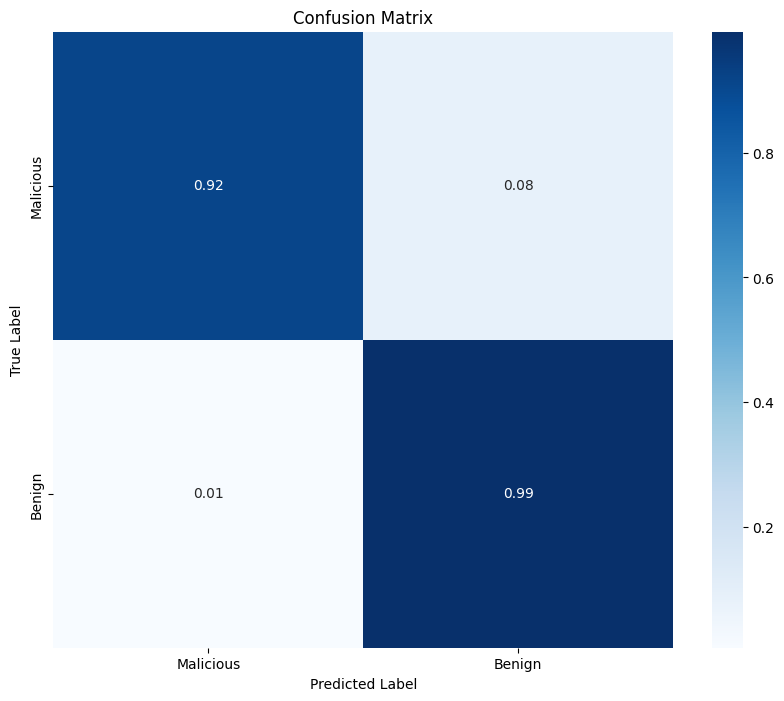

In [73]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_cm(y_true, y_pred, classes, normalize=False):
    """Plot confusion matrix."""

    classification_rep = classification_report(y_true, y_pred, target_names=classes)
    print(classification_rep)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)), normalize='true' if normalize else None)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Plot confusion matrix
plot_cm(y_true, y_pred, LE.classes_, normalize=True)

In [74]:
# create a popup notification when the notebook run is complete
import os
os.system("notify-send 'Notebook run complete'")


1